# Chapter 8.3: Feature Stores & Real-time Features

## Learning Objectives

By the end of this notebook, you will be able to:

1. Describe the three-tier feature store architecture (offline, nearline, online)
2. Understand the Feast framework for feature registration, serving, and monitoring
3. Explain how Tecton and similar managed platforms extend basic feature stores
4. Implement real-time feature computation with streaming aggregations
5. Analyze how feature freshness affects recommendation quality
6. Apply point-in-time correctness to avoid feature leakage in training
7. Build a mini feature store with online/offline serving capabilities

## Prerequisites

- Understanding of recommendation system architecture (Part 1)
- Basic Python and dictionary/database concepts
- Familiarity with time-series data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part8/chapter_8.3_feature_stores.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part8/chapter_8.3_feature_stores.ipynb)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Any, Tuple
from dataclasses import dataclass, field
from datetime import datetime, timedelta
from collections import defaultdict, deque
import time
import json
import hashlib

np.random.seed(42)
plt.style.use('seaborn-v0_8')
print("Feature Store Simulation Environment Ready")

Feature Store Simulation Environment Ready


## 1. Feature Store Architecture

A **feature store** is a centralized system for managing, storing, and serving features for ML models. In recommendation systems, it bridges the gap between feature engineering and model serving.

### Three-Tier Architecture

| Tier | Storage | Latency | Use Case |
|------|---------|---------|----------|
| **Offline** | Data warehouse (Hive, BigQuery) | Minutes-Hours | Training data generation |
| **Nearline** | Stream processor (Flink, Spark) | Seconds-Minutes | Aggregated features |
| **Online** | Key-value store (Redis, DynamoDB) | <10ms | Real-time serving |

> **\U0001f4a1 Concept:** The key challenge is **consistency** -- training features (offline) must match serving features (online). This is called the "training-serving skew" problem, and it's one of the most common sources of bugs in production ML systems.

In [2]:
@dataclass
class FeatureDefinition:
    """Defines a feature with its metadata."""
    name: str
    entity: str  # e.g., "user", "item"
    dtype: str  # e.g., "float", "int", "vector"
    description: str
    freshness_requirement: timedelta  # Max acceptable staleness
    source: str  # "batch", "stream", "on_demand"
    default_value: Any = 0.0
    ttl: Optional[timedelta] = None  # Time to live

@dataclass
class FeatureValue:
    """A timestamped feature value."""
    value: Any
    timestamp: datetime
    feature_name: str
    entity_id: str


class OfflineStore:
    """Simulates offline feature store (like a data warehouse)."""
    
    def __init__(self):
        # entity_id -> feature_name -> List[(timestamp, value)]
        self.data: Dict[str, Dict[str, List[Tuple[datetime, Any]]]] = defaultdict(
            lambda: defaultdict(list)
        )
    
    def write(self, entity_id: str, feature_name: str, value: Any, timestamp: datetime):
        self.data[entity_id][feature_name].append((timestamp, value))
        self.data[entity_id][feature_name].sort(key=lambda x: x[0])
    
    def get_historical(
        self, entity_id: str, feature_name: str,
        start: datetime, end: datetime
    ) -> List[Tuple[datetime, Any]]:
        """Get all feature values in a time range."""
        values = self.data.get(entity_id, {}).get(feature_name, [])
        return [(ts, v) for ts, v in values if start <= ts <= end]
    
    def point_in_time_lookup(
        self, entity_id: str, feature_name: str, as_of: datetime
    ) -> Optional[Any]:
        """Get the feature value as it was at a specific point in time."""
        values = self.data.get(entity_id, {}).get(feature_name, [])
        # Find the latest value before as_of
        result = None
        for ts, v in values:
            if ts <= as_of:
                result = v
            else:
                break
        return result


class OnlineStore:
    """Simulates online feature store (like Redis)."""
    
    def __init__(self):
        # entity_id -> feature_name -> (value, timestamp)
        self.data: Dict[str, Dict[str, Tuple[Any, datetime]]] = defaultdict(dict)
        self.read_latency_ms = 1.0  # Simulated latency
        self.read_count = 0
    
    def write(self, entity_id: str, feature_name: str, value: Any, timestamp: datetime):
        self.data[entity_id][feature_name] = (value, timestamp)
    
    def read(self, entity_id: str, feature_names: List[str]) -> Dict[str, Any]:
        self.read_count += 1
        result = {}
        entity_data = self.data.get(entity_id, {})
        for fname in feature_names:
            if fname in entity_data:
                result[fname] = entity_data[fname][0]  # Just the value
        return result
    
    def read_batch(self, entity_ids: List[str], feature_names: List[str]) -> List[Dict[str, Any]]:
        return [self.read(eid, feature_names) for eid in entity_ids]


class NearlineStore:
    """Simulates nearline computation with streaming aggregations."""
    
    def __init__(self, window_size: timedelta = timedelta(hours=1)):
        self.window_size = window_size
        # entity_id -> deque of (timestamp, event_data)
        self.event_buffer: Dict[str, deque] = defaultdict(deque)
        self.aggregations: Dict[str, Dict[str, Any]] = defaultdict(dict)
    
    def ingest_event(self, entity_id: str, event_data: Dict, timestamp: datetime):
        self.event_buffer[entity_id].append((timestamp, event_data))
        self._expire_old_events(entity_id, timestamp)
        self._recompute_aggregations(entity_id, timestamp)
    
    def _expire_old_events(self, entity_id: str, current_time: datetime):
        buffer = self.event_buffer[entity_id]
        cutoff = current_time - self.window_size
        while buffer and buffer[0][0] < cutoff:
            buffer.popleft()
    
    def _recompute_aggregations(self, entity_id: str, current_time: datetime):
        events = self.event_buffer[entity_id]
        if not events:
            return
        
        self.aggregations[entity_id] = {
            'event_count_1h': len(events),
            'last_event_time': events[-1][0],
            'seconds_since_last': (current_time - events[-1][0]).total_seconds(),
        }
    
    def get_features(self, entity_id: str) -> Dict[str, Any]:
        return self.aggregations.get(entity_id, {})


# Build a simple 3-tier feature store
offline = OfflineStore()
online = OnlineStore()
nearline = NearlineStore()

# Populate with synthetic data
base_time = datetime(2024, 1, 1)
num_users = 100

for uid in range(num_users):
    user_id = f"user_{uid}"
    # Offline: historical features
    for day in range(30):
        ts = base_time + timedelta(days=day)
        offline.write(user_id, "daily_clicks", np.random.poisson(5), ts)
        offline.write(user_id, "daily_purchases", np.random.poisson(0.5), ts)
    
    # Online: latest features
    online.write(user_id, "user_embedding", np.random.randn(64).tolist(), base_time + timedelta(days=30))
    online.write(user_id, "account_age_days", 365 + np.random.randint(0, 1000), base_time + timedelta(days=30))

print(f"Offline store: {sum(len(v) for d in offline.data.values() for v in d.values())} records")
print(f"Online store: {sum(len(v) for v in online.data.values())} features")
print(f"Nearline store: ready for streaming events")

Offline store: 6000 records
Online store: 200 features
Nearline store: ready for streaming events


## 2. Feast Framework Overview

**Feast** (Feature Store) is an open-source feature store originally developed by Gojek and Google. It provides:

1. **Feature Registry**: Central catalog of all features with metadata
2. **Materialization**: Pipeline to move features from offline to online store
3. **Serving**: Low-latency online feature retrieval
4. **Point-in-time joins**: Correct historical feature retrieval for training

Let's simulate these concepts.

In [3]:
class FeatureRegistry:
    """Central registry of all feature definitions (like Feast's registry)."""
    
    def __init__(self):
        self.features: Dict[str, FeatureDefinition] = {}
        self.feature_views: Dict[str, List[str]] = {}  # view_name -> [feature_names]
    
    def register_feature(self, feature: FeatureDefinition):
        self.features[feature.name] = feature
        print(f"  Registered: {feature.name} ({feature.entity}, {feature.source})")
    
    def register_view(self, view_name: str, feature_names: List[str]):
        self.feature_views[view_name] = feature_names
    
    def get_features_for_entity(self, entity: str) -> List[FeatureDefinition]:
        return [f for f in self.features.values() if f.entity == entity]
    
    def describe(self):
        print("\nFeature Registry")
        print("=" * 80)
        print(f"{'Name':<30} {'Entity':<10} {'Source':<10} {'Freshness':<15} {'Type':<8}")
        print("-" * 80)
        for f in self.features.values():
            fresh = str(f.freshness_requirement)
            print(f"{f.name:<30} {f.entity:<10} {f.source:<10} {fresh:<15} {f.dtype:<8}")


class MiniFeatureStore:
    """A mini feature store combining registry, offline, online, and nearline stores."""
    
    def __init__(self):
        self.registry = FeatureRegistry()
        self.offline = OfflineStore()
        self.online = OnlineStore()
        self.nearline = NearlineStore()
    
    def register_feature(self, feature: FeatureDefinition):
        self.registry.register_feature(feature)
    
    def materialize(self, entity_id: str, feature_name: str, as_of: datetime):
        """Move features from offline to online store (materialization)."""
        value = self.offline.point_in_time_lookup(entity_id, feature_name, as_of)
        if value is not None:
            self.online.write(entity_id, feature_name, value, as_of)
    
    def get_online_features(
        self, entity_ids: List[str], feature_names: List[str]
    ) -> List[Dict[str, Any]]:
        """Get features for serving (low latency)."""
        results = []
        for eid in entity_ids:
            features = self.online.read(eid, feature_names)
            # Fill defaults for missing features
            for fname in feature_names:
                if fname not in features:
                    fdef = self.registry.features.get(fname)
                    features[fname] = fdef.default_value if fdef else None
            # Add nearline features
            nearline_feats = self.nearline.get_features(eid)
            for fname in feature_names:
                if fname in nearline_feats:
                    features[fname] = nearline_feats[fname]
            results.append(features)
        return results
    
    def get_training_features(
        self, entity_ids: List[str], feature_names: List[str],
        timestamps: List[datetime]
    ) -> List[Dict[str, Any]]:
        """Point-in-time correct feature retrieval for training."""
        results = []
        for eid, ts in zip(entity_ids, timestamps):
            features = {}
            for fname in feature_names:
                value = self.offline.point_in_time_lookup(eid, fname, ts)
                if value is None:
                    fdef = self.registry.features.get(fname)
                    value = fdef.default_value if fdef else None
                features[fname] = value
            results.append(features)
        return results

# Set up the feature store
fs = MiniFeatureStore()

print("Registering features:")
features_to_register = [
    FeatureDefinition("user_click_count_7d", "user", "float", "Total clicks in past 7 days",
                      timedelta(hours=1), "batch", 0.0),
    FeatureDefinition("user_purchase_count_7d", "user", "float", "Total purchases in past 7 days",
                      timedelta(hours=1), "batch", 0.0),
    FeatureDefinition("user_session_clicks_1h", "user", "int", "Clicks in current session",
                      timedelta(seconds=30), "stream", 0),
    FeatureDefinition("item_ctr_7d", "item", "float", "Item CTR over past 7 days",
                      timedelta(hours=6), "batch", 0.01),
    FeatureDefinition("item_view_count_1h", "item", "int", "Item views in past hour",
                      timedelta(minutes=5), "stream", 0),
    FeatureDefinition("user_embedding", "user", "vector", "User embedding from collaborative filtering",
                      timedelta(days=1), "batch"),
]

for f in features_to_register:
    fs.register_feature(f)

fs.registry.describe()

Registering features:
  Registered: user_click_count_7d (user, batch)
  Registered: user_purchase_count_7d (user, batch)
  Registered: user_session_clicks_1h (user, stream)
  Registered: item_ctr_7d (item, batch)
  Registered: item_view_count_1h (item, stream)
  Registered: user_embedding (user, batch)

Feature Registry
Name                           Entity     Source     Freshness       Type    
--------------------------------------------------------------------------------
user_click_count_7d            user       batch      1:00:00         float   
user_purchase_count_7d         user       batch      1:00:00         float   
user_session_clicks_1h         user       stream     0:00:30         int     
item_ctr_7d                    item       batch      6:00:00         float   
item_view_count_1h             item       stream     0:05:00         int     
user_embedding                 user       batch      1 day, 0:00:00  vector  


## 3. Real-Time Feature Computation

Real-time features are computed on streaming events. Common patterns:

- **Sliding window aggregations**: count, sum, avg over last N minutes/hours
- **Session features**: events within current user session
- **Decay-weighted features**: exponentially decaying importance of past events

$$f_{\text{decay}}(t) = \sum_{i} w_i \cdot e^{-\lambda(t - t_i)}$$

> **\u26a0\ufe0f Common Pitfall:** Real-time features can be expensive to compute. A common mistake is computing too many complex aggregations per request. The rule of thumb: keep online computation under 5ms per request.

In [4]:
class StreamingFeatureComputer:
    """Computes real-time features from streaming events."""
    
    def __init__(self, windows: List[timedelta]):
        self.windows = sorted(windows)
        # entity -> deque of (timestamp, event_type, event_value)
        self.buffers: Dict[str, deque] = defaultdict(deque)
        self.max_window = max(windows)
    
    def process_event(
        self, entity_id: str, event_type: str, 
        event_value: float, timestamp: datetime
    ):
        self.buffers[entity_id].append((timestamp, event_type, event_value))
        # Expire old events
        cutoff = timestamp - self.max_window
        while self.buffers[entity_id] and self.buffers[entity_id][0][0] < cutoff:
            self.buffers[entity_id].popleft()
    
    def get_features(self, entity_id: str, current_time: datetime) -> Dict[str, float]:
        features = {}
        events = self.buffers.get(entity_id, deque())
        
        for window in self.windows:
            window_label = self._window_label(window)
            cutoff = current_time - window
            
            window_events = [(ts, et, ev) for ts, et, ev in events if ts >= cutoff]
            
            # Count features
            event_types = defaultdict(int)
            event_values = defaultdict(float)
            for ts, et, ev in window_events:
                event_types[et] += 1
                event_values[et] += ev
            
            features[f"total_events_{window_label}"] = len(window_events)
            for et in ['click', 'view', 'purchase']:
                features[f"{et}_count_{window_label}"] = event_types.get(et, 0)
                features[f"{et}_value_{window_label}"] = event_values.get(et, 0.0)
            
            # Time since last event
            if window_events:
                last_ts = max(ts for ts, _, _ in window_events)
                features[f"seconds_since_last_{window_label}"] = (
                    current_time - last_ts
                ).total_seconds()
            else:
                features[f"seconds_since_last_{window_label}"] = window.total_seconds()
        
        return features
    
    @staticmethod
    def _window_label(window: timedelta) -> str:
        total_seconds = window.total_seconds()
        if total_seconds < 3600:
            return f"{int(total_seconds/60)}m"
        elif total_seconds < 86400:
            return f"{int(total_seconds/3600)}h"
        else:
            return f"{int(total_seconds/86400)}d"

# Simulate streaming events
computer = StreamingFeatureComputer(
    windows=[timedelta(minutes=5), timedelta(hours=1), timedelta(hours=24)]
)

base_time = datetime(2024, 1, 15, 12, 0, 0)
user_id = "user_42"

# Generate synthetic event stream
event_types = ['view', 'click', 'purchase']
event_probs = [0.6, 0.3, 0.1]

events_generated = 0
for minute in range(120):
    # Poisson arrival of events
    num_events = np.random.poisson(2)
    for _ in range(num_events):
        ts = base_time + timedelta(minutes=minute, seconds=np.random.randint(0, 60))
        et = np.random.choice(event_types, p=event_probs)
        ev = np.random.exponential(10.0) if et == 'purchase' else 1.0
        computer.process_event(user_id, et, ev, ts)
        events_generated += 1

# Get features at the end
query_time = base_time + timedelta(hours=2)
features = computer.get_features(user_id, query_time)

print(f"Generated {events_generated} events over 2 hours")
print(f"\nReal-time features for {user_id}:")
for k, v in sorted(features.items()):
    print(f"  {k}: {v}")

Generated 237 events over 2 hours

Real-time features for user_42:
  click_count_1d: 77
  click_count_1h: 33
  click_count_5m: 3
  click_value_1d: 77.0
  click_value_1h: 33.0
  click_value_5m: 3.0
  purchase_count_1d: 25
  purchase_count_1h: 12
  purchase_count_5m: 2
  purchase_value_1d: 219.15181698755856
  purchase_value_1h: 92.92661453667033
  purchase_value_5m: 12.339941767721374
  seconds_since_last_1d: 22.0
  seconds_since_last_1h: 22.0
  seconds_since_last_5m: 22.0
  total_events_1d: 237
  total_events_1h: 112
  total_events_5m: 15
  view_count_1d: 135
  view_count_1h: 67
  view_count_5m: 10
  view_value_1d: 135.0
  view_value_1h: 67.0
  view_value_5m: 10.0


## 4. Feature Freshness and Quality Impact

**Feature freshness** measures how recently a feature was computed. Stale features can significantly hurt recommendation quality.

The impact depends on:
- **Feature volatility**: How quickly the underlying signal changes
- **Feature importance**: How much the model relies on this feature
- **System latency**: How old features are by the time they're served

> **\U0001f511 Pro Tip:** Not all features need to be fresh. User demographics change slowly (refresh daily), but session-level features like "items viewed in last 5 minutes" must be near-real-time.

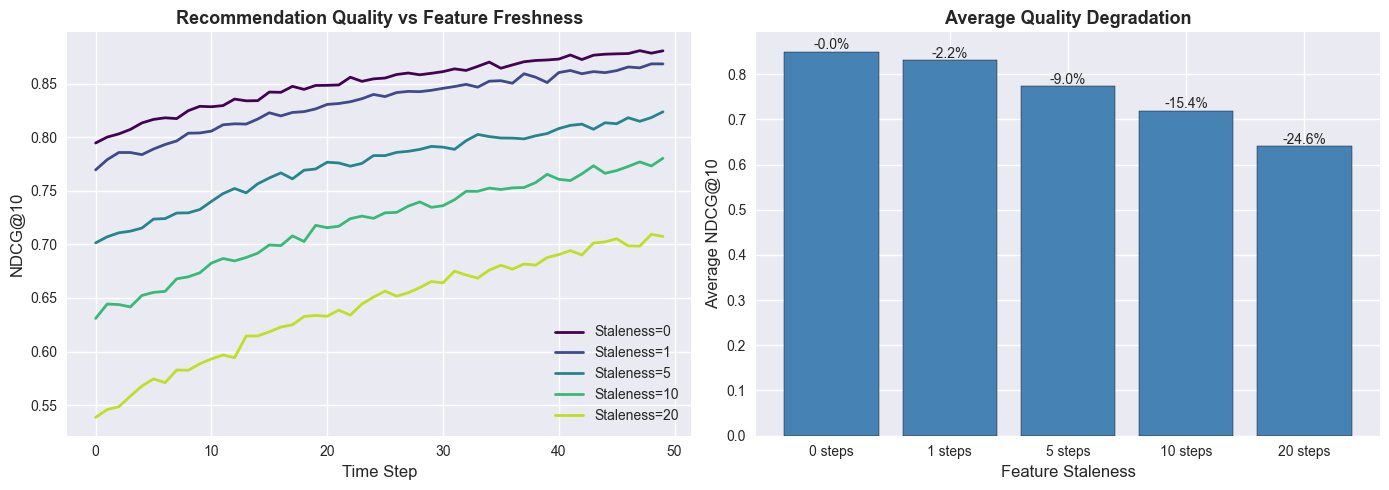

In [5]:
def simulate_freshness_impact(
    num_users: int = 1000,
    num_items: int = 100,
    num_steps: int = 50,
    staleness_levels: List[int] = None,
) -> Dict[int, List[float]]:
    """Simulate how feature staleness affects recommendation quality."""
    if staleness_levels is None:
        staleness_levels = [0, 1, 5, 10, 20]
    
    # True user preferences evolve over time (random walk)
    true_preferences = np.random.randn(num_users, num_items) * 0.5
    
    results = {s: [] for s in staleness_levels}
    
    for step in range(num_steps):
        # Preferences drift
        drift = np.random.randn(num_users, num_items) * 0.1
        true_preferences += drift
        
        for staleness in staleness_levels:
            if staleness == 0:
                # Fresh features: observe current preferences with noise
                observed = true_preferences + np.random.randn(num_users, num_items) * 0.2
            else:
                # Stale features: use preferences from `staleness` steps ago
                # Approximated by adding accumulated drift noise
                stale_drift = np.random.randn(num_users, num_items) * 0.1 * np.sqrt(staleness)
                observed = true_preferences - stale_drift + np.random.randn(num_users, num_items) * 0.2
            
            # Compute recommendation quality (NDCG@10 approximation)
            k = 10
            ndcg_scores = []
            for u in range(num_users):
                true_top_k = set(np.argsort(-true_preferences[u])[:k])
                pred_top_k = list(np.argsort(-observed[u])[:k])
                
                # Simplified NDCG
                dcg = sum(
                    1.0 / np.log2(rank + 2) 
                    for rank, item in enumerate(pred_top_k) 
                    if item in true_top_k
                )
                ideal_dcg = sum(1.0 / np.log2(i + 2) for i in range(min(k, len(true_top_k))))
                ndcg_scores.append(dcg / ideal_dcg if ideal_dcg > 0 else 0)
            
            results[staleness].append(np.mean(ndcg_scores))
    
    return results

# Run simulation
freshness_results = simulate_freshness_impact()

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0, 0.9, len(freshness_results)))
for (staleness, scores), color in zip(freshness_results.items(), colors):
    ax1.plot(scores, label=f'Staleness={staleness}', color=color, linewidth=2)

ax1.set_xlabel('Time Step', fontsize=12)
ax1.set_ylabel('NDCG@10', fontsize=12)
ax1.set_title('Recommendation Quality vs Feature Freshness', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)

# Average quality by staleness
staleness_levels = sorted(freshness_results.keys())
avg_quality = [np.mean(freshness_results[s]) for s in staleness_levels]

ax2.bar(range(len(staleness_levels)), avg_quality, color='steelblue', edgecolor='black')
ax2.set_xticks(range(len(staleness_levels)))
ax2.set_xticklabels([f'{s} steps' for s in staleness_levels])
ax2.set_xlabel('Feature Staleness', fontsize=12)
ax2.set_ylabel('Average NDCG@10', fontsize=12)
ax2.set_title('Average Quality Degradation', fontsize=13, fontweight='bold')

for i, v in enumerate(avg_quality):
    pct_drop = (1 - v / avg_quality[0]) * 100
    ax2.text(i, v + 0.005, f'-{pct_drop:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_freshness.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Point-in-Time Correctness

**Point-in-time (PIT) correctness** means that when creating training data, we only use features that were available at the time of the original event.

Without PIT correctness, we get **feature leakage** -- the model sees future information during training but not during serving, leading to overfit models that fail in production.

Example: If predicting whether user U clicks item I at time T, we must use:
- User features as of time T (not T+1)
- Item features as of time T
- No aggregate features that include event T itself

> **\u26a0\ufe0f Common Pitfall:** A surprisingly common bug: using a feature like "user_total_purchases" that includes the purchase event you're trying to predict. This gives 95% AUC offline but no improvement online.

Point-in-Time Correctness Demo
Predicting purchase for user_42 on day 5
Daily purchases: [2, 3, 0, 5, 1, 4, 2, 6, 0, 3]

CORRECT (day 4 features): cumulative_purchases = 11
INCORRECT (day 5 features): cumulative_purchases = 15 (includes day 5!)
INCORRECT (day 9 features): cumulative_purchases = 26 (future leakage!)


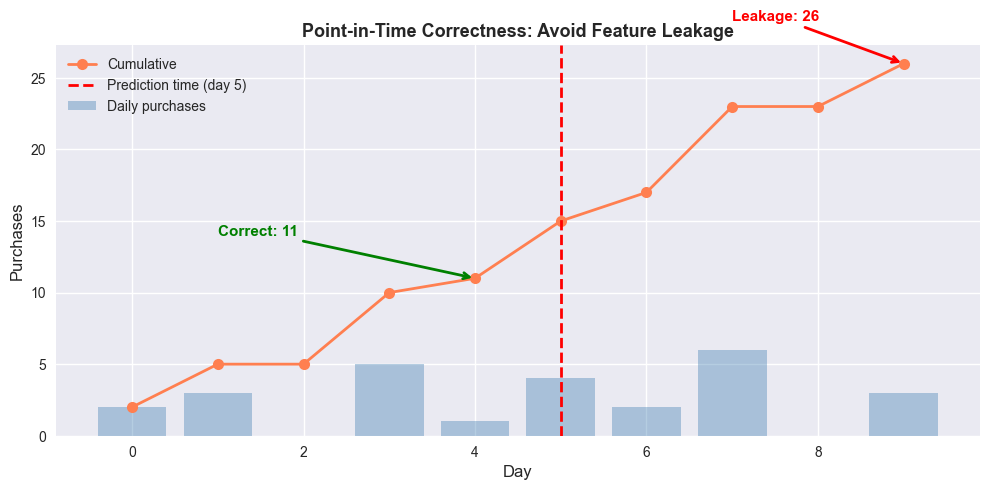

In [6]:
def demonstrate_pit_correctness():
    """Show the difference between correct and incorrect point-in-time joins."""
    
    offline_store = OfflineStore()
    base = datetime(2024, 1, 1)
    
    # Populate: user_42's purchase count increases over time
    user_id = "user_42"
    daily_purchases = [2, 3, 0, 5, 1, 4, 2, 6, 0, 3]  # 10 days
    cumulative = 0
    for day, purchases in enumerate(daily_purchases):
        cumulative += purchases
        ts = base + timedelta(days=day)
        offline_store.write(user_id, "cumulative_purchases", cumulative, ts)
        offline_store.write(user_id, "daily_purchases", purchases, ts)
    
    # Training events: predict purchase on day 5
    prediction_time = base + timedelta(days=5)
    
    # CORRECT: Use features as of day 4 (before the event)
    correct_feature = offline_store.point_in_time_lookup(
        user_id, "cumulative_purchases", prediction_time - timedelta(days=1)
    )
    
    # INCORRECT: Use features from the future (day 9)
    incorrect_feature = offline_store.point_in_time_lookup(
        user_id, "cumulative_purchases", base + timedelta(days=9)
    )
    
    # ALSO INCORRECT: Use features from the same day (includes leakage)
    sameday_feature = offline_store.point_in_time_lookup(
        user_id, "cumulative_purchases", prediction_time
    )
    
    print("Point-in-Time Correctness Demo")
    print("=" * 60)
    print(f"Predicting purchase for {user_id} on day 5")
    print(f"Daily purchases: {daily_purchases}")
    print()
    print(f"CORRECT (day 4 features): cumulative_purchases = {correct_feature}")
    print(f"INCORRECT (day 5 features): cumulative_purchases = {sameday_feature} (includes day 5!)")
    print(f"INCORRECT (day 9 features): cumulative_purchases = {incorrect_feature} (future leakage!)")
    
    return daily_purchases, correct_feature, sameday_feature, incorrect_feature

daily_purchases, correct, sameday, future = demonstrate_pit_correctness()

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
days = range(len(daily_purchases))
cumulative = np.cumsum(daily_purchases)

ax.bar(days, daily_purchases, alpha=0.4, color='steelblue', label='Daily purchases')
ax.plot(days, cumulative, 'o-', color='coral', linewidth=2, markersize=8, label='Cumulative')

# Highlight prediction point
ax.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Prediction time (day 5)')
ax.annotate(f'Correct: {correct}', xy=(4, cumulative[4]), xytext=(1, cumulative[4]+3),
           arrowprops=dict(arrowstyle='->', color='green', lw=2),
           fontsize=11, color='green', fontweight='bold')
ax.annotate(f'Leakage: {future}', xy=(9, cumulative[9]), xytext=(7, cumulative[9]+3),
           arrowprops=dict(arrowstyle='->', color='red', lw=2),
           fontsize=11, color='red', fontweight='bold')

ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Purchases', fontsize=12)
ax.set_title('Point-in-Time Correctness: Avoid Feature Leakage', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('pit_correctness.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Exercises

### \U0001f3cb\ufe0f Exercise 1: Build a Complete Mini Feature Store

Build a feature store that supports materialization, serving, and monitoring.

In [7]:
# Exercise 1: Complete Mini Feature Store
# TODO: Add materialization pipeline and monitoring

class ProductionFeatureStore:
    """
    Feature store with:
    - Automatic materialization from offline to online
    - Feature quality monitoring (staleness, missing rate)
    - Batch and online serving
    """
    
    def __init__(self):
        self.registry = FeatureRegistry()
        self.offline = OfflineStore()
        self.online = OnlineStore()
        self.metrics = defaultdict(list)  # Track serving metrics
    
    def materialize_features(
        self, entity_ids: List[str], feature_names: List[str], as_of: datetime
    ):
        """TODO: Materialize features from offline to online store."""
        # For each entity and feature:
        # 1. Look up the latest value from offline store
        # 2. Write to online store
        # 3. Track metrics (how many were materialized, any missing)
        pass
    
    def serve_features(
        self, entity_ids: List[str], feature_names: List[str]
    ) -> Tuple[List[Dict[str, Any]], Dict[str, float]]:
        """
        TODO: Serve features with quality metrics.
        Returns: (features, quality_metrics)
        quality_metrics should include:
        - missing_rate: fraction of features that were missing
        - avg_staleness_seconds: average age of served features
        """
        pass
    
    def get_monitoring_dashboard(self) -> Dict:
        """TODO: Return monitoring statistics."""
        pass

### \U0001f3cb\ufe0f Exercise 2: Streaming Feature Aggregator

Implement a streaming aggregator that computes exponential-decay weighted features.

In [8]:
# Exercise 2: Exponential Decay Feature Aggregator
# TODO: Implement exponential decay weighted features

class ExponentialDecayAggregator:
    """
    Computes features with exponential time decay:
    f(t) = sum_i(value_i * exp(-lambda * (t - t_i)))
    
    This gives more weight to recent events.
    """
    
    def __init__(self, decay_rate: float = 0.01):
        # TODO: Initialize
        # decay_rate: lambda parameter (higher = faster decay)
        pass
    
    def add_event(self, entity_id: str, value: float, timestamp: datetime):
        # TODO: Store the event
        pass
    
    def get_decayed_sum(self, entity_id: str, query_time: datetime) -> float:
        # TODO: Compute the exponential-decay weighted sum
        pass

# Test: simulate a user with increasing engagement
# The decay-weighted feature should reflect recent activity more strongly

### \U0001f3cb\ufe0f Exercise 3: Feature Freshness Monitor

Build a monitoring system that alerts when features become too stale.

In [9]:
# Exercise 3: Feature Freshness Monitor
# TODO: Implement a monitoring system

class FreshnessMonitor:
    """
    Monitors feature freshness and raises alerts.
    
    For each feature, tracks:
    - Last update time
    - Average staleness
    - SLA violations (features served beyond freshness requirement)
    """
    
    def __init__(self, registry: FeatureRegistry):
        # TODO: Initialize monitoring state
        pass
    
    def record_serve(
        self, feature_name: str, feature_timestamp: datetime, serve_time: datetime
    ):
        # TODO: Record a feature serve event and check for SLA violations
        pass
    
    def get_alerts(self) -> List[str]:
        # TODO: Return list of alert messages for SLA violations
        pass
    
    def get_report(self) -> Dict:
        # TODO: Return monitoring report
        pass

## Summary

In this notebook, we covered:

1. **Feature Store Architecture**: Offline, nearline, and online tiers serving different latency requirements
2. **Feast-style Feature Registry**: Central catalog for feature definitions and metadata
3. **Real-time Feature Computation**: Streaming aggregations with sliding windows and decay functions
4. **Feature Freshness**: How stale features degrade recommendation quality, and which features need real-time updates
5. **Point-in-time Correctness**: Avoiding feature leakage by using only historically available features for training

### Key References

- "Feast: Feature Store for Machine Learning" (Gojek/Google, open-source)
- "Tecton: Enterprise Feature Platform" (Tecton AI)
- Zhao et al. "Real-time Feature Engineering at Scale" (Meta, 2022)
- Orr et al. "Managing ML Feature Stores at Scale" (LinkedIn, 2021)

### Next Steps

In Chapter 8.4, we will explore **ID vs ID-free Systems** -- the fundamental design choice between unique ID embeddings and content-based representations.